In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()
con.execute(open('sql/schema.sql').read())

## Vulnerability Ranking
Ranks every tract by a composite score weighted on poverty, education, and SNAP usage.

In [2]:
df_vuln = con.execute(open('sql/queries/01_vulnerability_ranking.sql').read()).df()
df_vuln.head(10)

,tract,poverty_rate,percent_no_hs,snap_rate,OBESITY_CrudePrev,vulnerability_score
0,31.03,21.8,21.618037,42.89,42.4,0.3018
1,4.00,30.9,28.962331,27.91,41.1,0.2912
2,18.00,56.7,9.222423,14.07,39.5,0.2540
3,20.02,38.4,19.296317,18.54,40.7,0.2472
4,6.00,63.7,0.000000,11.54,31.9,0.2373
5,8.00,27.6,16.712080,20.95,38.4,0.2167
6,20.01,25.8,13.452299,22.33,41.0,0.2071
7,21.00,27.6,17.034422,16.88,37.7,0.2014
8,17.00,23.8,17.808219,18.95,41.3,0.2006
9,31.04,14.5,27.440253,18.17,41.1,0.1985


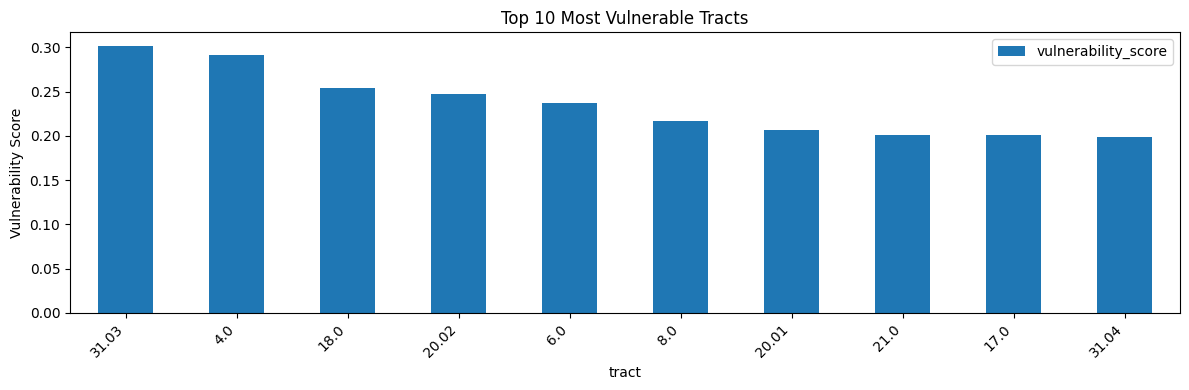

In [3]:
df_vuln.head(10).plot(x='tract', y='vulnerability_score', kind='bar', figsize=(12, 4))
plt.title('Top 10 Most Vulnerable Tracts')
plt.ylabel('Vulnerability Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## SNAP Outliers
Tracts with high SNAP usage but unexpectedly low obesity. Potential targets for food access interventions.

In [4]:
df_snap = con.execute(open('sql/queries/02_snap_outliers.sql').read()).df()
df_snap

,tract,snap_rate,OBESITY_CrudePrev,poverty_rate,dist_to_grocery_km
0,10.03,15.54,34.3,11.4,0.500515


## Food Access vs Health Outcomes
Groups tracts by grocery proximity and compares average obesity, poverty, and SNAP rates.

In [5]:
df_access = con.execute(open('sql/queries/03_composite_score.sql').read()).df()
df_access

,access_tier,avg_obesity,avg_poverty,avg_snap,tract_count
0,Near grocery,36.42,20.11,12.17,35
1,Far from grocery,33.96,5.30,2.25,5
2,Moderate access,33.71,8.36,5.47,38


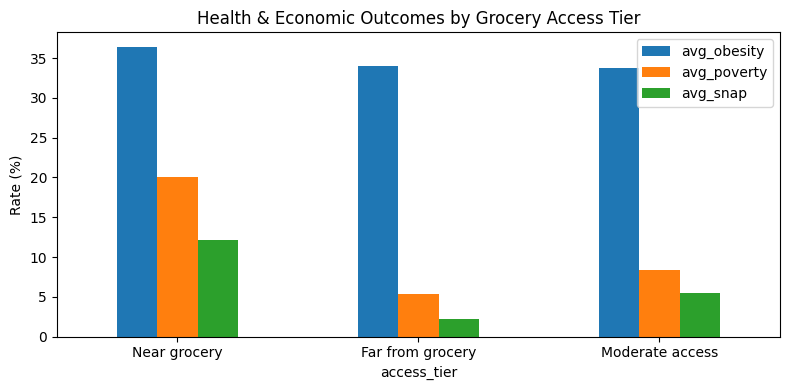

In [6]:
df_access.plot(x='access_tier', y=['avg_obesity', 'avg_poverty', 'avg_snap'], kind='bar', figsize=(8, 4))
plt.title('Health & Economic Outcomes by Grocery Access Tier')
plt.ylabel('Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Full Tract Profiles

In [7]:
df_profiles = con.execute(open('sql/queries/04_tract_profiles.sql').read()).df()
df_profiles

,tract,poverty_rate,percent_no_hs,percent_uninsured,percent_no_car,median_income,OBESITY_CrudePrev,DIABETES_CrudePrev,CHD_CrudePrev,dist_to_grocery_km,fast_food_density,snap_rate,pct_under_18,pct_65_plus
0,1.00,12.8,13.973799,6.4,13.838447,48425.0,40.1,12.8,7.6,0.601010,0.093775,14.65,24.45,19.00
1,2.01,16.4,2.857143,5.0,10.810811,55791.0,35.9,11.0,7.0,0.814400,0.216570,9.62,19.92,18.04
2,2.02,23.8,3.939394,5.7,9.119696,45597.0,37.3,9.1,4.9,0.701588,0.000000,23.45,15.31,11.31
3,3.00,19.9,11.961367,13.7,7.757758,55339.0,37.8,10.2,5.5,0.370132,0.342504,17.31,25.45,9.09
4,4.00,30.9,28.962331,16.1,4.530281,47457.0,41.1,11.8,5.7,0.726821,0.230020,27.91,28.16,7.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,102.03,6.7,4.351204,3.3,6.879607,142083.0,31.6,7.5,4.4,1.567109,0.065606,0.95,28.93,8.55
74,102.04,13.6,6.913891,4.5,1.875293,81212.0,33.2,6.8,3.1,2.598271,0.000000,2.43,26.39,4.49
75,103.00,4.9,1.474654,3.6,2.663578,123875.0,34.3,10.0,5.9,15.309227,0.000000,5.64,22.57,22.85
76,104.01,1.6,1.742919,1.4,2.745098,117669.0,33.4,7.7,4.4,2.308100,0.004867,3.45,35.74,13.15
